# 07 · End-to-end inference on real-world `data_test/`
Pose → tagger (active region) → **recognition-driven spotting** (04b) → open-set status (E1 calibration) → Face model → LLM fusion (OpenAI, constrained to the Sign model's candidates) → **deterministic evidence guard** (a sentence is shown only if ≥1 sign is accepted and ≥ half of the signs are resolved). **Audio and on-screen text of the test videos are never used.**

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'modules').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = ['Tahoma', 'Leelawadee UI', 'DejaVu Sans']
from IPython.display import display, Image, Audio, Markdown
from modules.utils import ART, read_json
REP, V4, MAN4 = ART / 'reports', ART / 'v4', ART / 'manifests_v4'
pd.set_option('display.max_colwidth', 80)

In [2]:
from modules.pipeline_v4 import SignPipelineV4
pipe = SignPipelineV4()

## ฉันปลอบเพื่อนร้องไห้

,t0,t1,status,nearest,score,margin,top5
0,1.60,3.68,uncertain,เพื่อน,0.757,0.053,"เพื่อน, มิตรภาพ, เพื่อนสนิท, เย็บผ้า, ถักโครเชต์"
1,3.68,6.08,uncertain,จมูกแบน,0.608,0.043,"จมูกแบน, ร้องไห้, สายตาดี, มอง, จมูก"
2,6.08,8.48,unknown,ไม่พอ,0.548,0.016,"ไม่พอ, ภาคเหนือ, องศา, นครปฐม, ไม้ตรี"
3,8.48,9.60,accepted,สะโพก,0.681,0.124,"สะโพก, ผิวปาก, ท้อง, บุกรุก, กระโถนถ่าย"


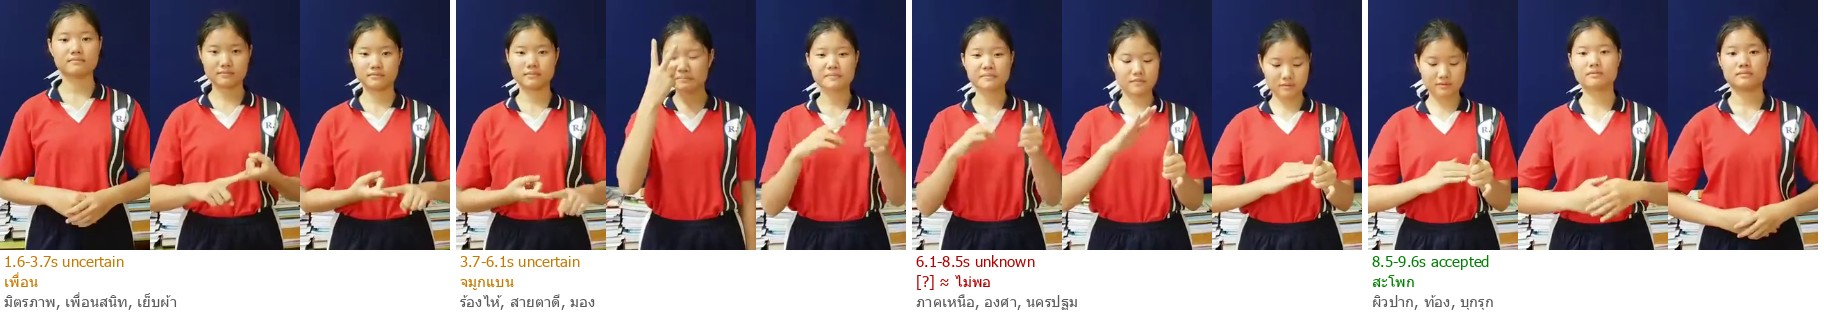

**Evidence (Sign model only):** เพื่อน? | จมูกแบน? | [?]≈ไม่พอ | สะโพก  
**Sentence:** — withheld —  
**Guard:** None · tentative LLM reading (not shown to users): None  
**Meaning:** จับได้คำว่า เพื่อน จมูก และ สะโพก เท่านั้น ส่วนคำที่สามไม่แน่ใจ  
**Emotion:** สีหน้าเป็นกลาง ไม่มีน้ำเสียงคำถามหรือปฏิเสธ  
**Chosen:** ['เพื่อน', 'จมูก', '[?]', 'สะโพก'] · confidence 0.3 · openai  
**Notes:** ไม่แน่ใจคำที่สาม ช่วงเวลาที่ 6.08-8.48 ว่าคำใดถูกต้องใน candidates: ไม่พอ, ภาคเหนือ, องศา, นครปฐม, ไม้ตรี

face: neutral False | timings: {'pose_ms': 3849.7, 'segmentation_ms': 780.1, 'recognition_ms': 4289.9, 'face_ms': 563.0, 'llm_ms': 4033.8}


## ไปทานข้าวด้วยกันมั้ย

,t0,t1,status,nearest,score,margin,top5
0,0.00,2.40,uncertain,คุณ,0.607,0.018,"คุณ, ทวิภาค, ข้าวเหนียว, ปาก, หนึ่งหมื่น"
1,2.40,4.16,uncertain,ศูนย์,0.587,0.025,"ศูนย์, งูเห่า, แปดสิบ, มิลลิลิตร, หนึ่งร้อยสอง"
2,4.16,6.56,uncertain,กินอาหารเหล่านั้นไม่ได้,0.639,0.006,"กินอาหารเหล่านั้นไม่ได้, กลับบ้าน, ถ่มน้ำลาย, ดอกเบี้ย, ไปแล้ว"


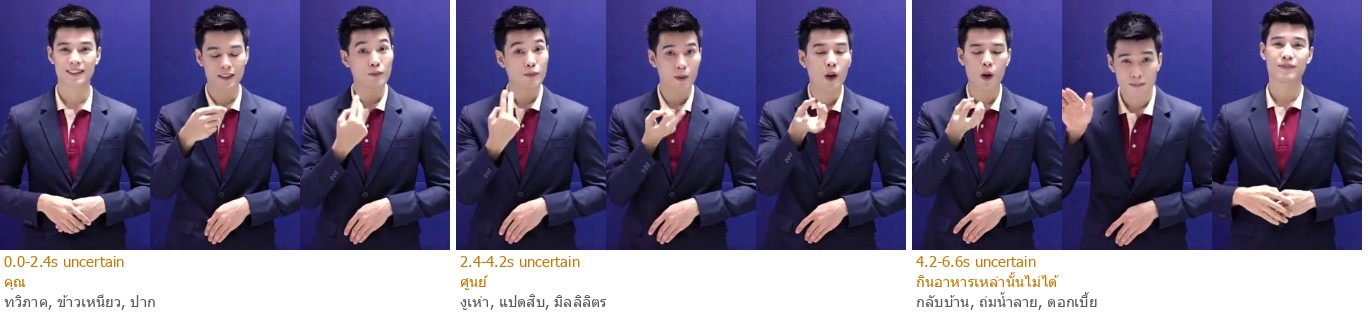

**Evidence (Sign model only):** คุณ? | ศูนย์? | กินอาหารเหล่านั้นไม่ได้?  
**Sentence:** — withheld —  
**Guard:** sentence withheld: no accepted sign · tentative LLM reading (not shown to users): คุณกินอาหารเหล่านั้นไม่ได้  
**Meaning:** ตรวจพบท่ามือ 3 ช่วง แต่หลักฐานไม่พอจะแปลเป็นประโยคอย่างมั่นใจ — คำที่ใกล้ที่สุดที่ระบบเคยเรียน: ช่วง 1 ≈ คุณ, ช่วง 2 ≈ ศูนย์, ช่วง 3 ≈ กินอาหารเหล่านั้นไม่ได้  
**Emotion:** สีหน้าเป็นกลาง ไม่มีคำถามหรือปฏิเสธ  
**Chosen:** ['คุณ', 'ศูนย์', 'กินอาหารเหล่านั้นไม่ได้'] · confidence 0.3 · openai  
**Notes:** คำทั้งหมดเป็น uncertain แต่เลือกคำที่เหมาะสมที่สุดตามบริบท

face: neutral False | timings: {'pose_ms': 1867.8, 'segmentation_ms': 105.0, 'recognition_ms': 3051.9, 'face_ms': 217.1, 'llm_ms': 1773.7}


In [3]:
results = {}
for stem in ['ฉันปลอบเพื่อนร้องไห้', 'ไปทานข้าวด้วยกันมั้ย']:
    out = ROOT/'result_reporting'/'inference_v4_notebook'/stem
    r = pipe.run(ROOT/'data_test'/f'{stem}.mp4', out, tts=True); results[stem] = r
    display(Markdown(f'## {stem}'))
    display(pd.DataFrame([dict(t0=s['t0'], t1=s['t1'], status=s['status'], nearest=s['nearest'], score=round(s['score'],3), margin=round(s['margin'],3), top5=', '.join(c['word'] for c in s['candidates'])) for s in r['segments']]))
    display(Image(filename=str(out/'segments.jpg')))
    f = r['fusion']; display(Markdown(f"**Evidence (Sign model only):** {f.get('evidence_gloss')}  \n**Sentence:** {f.get('sentence_th') or '— withheld —'}  \n**Guard:** {f.get('evidence_guard')} · tentative LLM reading (not shown to users): {f.get('tentative_sentence_th')}  \n**Meaning:** {f.get('meaning_th')}  \n**Emotion:** {f.get('emotion_th')}  \n**Chosen:** {f.get('chosen')} · confidence {f.get('confidence')} · {f.get('provider')}  \n**Notes:** {f.get('notes')}"))
    print('face:', r['face'].get('emotion'), r['face'].get('nmm', {}).get('question_yesno'), '| timings:', r['timings_ms'])
    if (out/'audio.wav').exists(): display(Audio(filename=str(out/'audio.wav')))